In [1]:
import numpy as np

# Gibbs sampling for a bivariate normal distribution
def gibbs_sampling(row = 0.5, num_samples = 1000):
    samples = np.zeros((num_samples, 2))
    x, y = 0, 0  # Initial values

    for i in range(num_samples):
        x = np.random.normal(row * y, (1 - row**2))
        y = np.random.normal(row * x, (1 - row**2))
        samples[i] = [x, y]

    return samples

In [2]:
# plot the samples
import matplotlib.pyplot as plt
def plot_samples(samples, title):
    plt.scatter(samples[:, 0], samples[:, 1])
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.grid()
    plt.show()

# also display the best fit line
def plot_samples_with_fit_line(samples, title):
    plt.scatter(samples[:, 0], samples[:, 1])
    plt.title(title)
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.axis('equal')
    plt.grid()
    
    # Fit a line to the samples
    m, b = np.polyfit(samples[:, 0], samples[:, 1], 1)
    x_fit = np.linspace(min(samples[:, 0]), max(samples[:, 0]), 100)
    y_fit = m * x_fit + b
    plt.plot(x_fit, y_fit, color='red', label=f'Fit line: y={m:.2f}x+{b:.2f}')
    plt.legend()
    plt.show()

# Display the histogram of the samples
def plot_histogram(samples, title):
    plt.hist2d(samples[:, 0], samples[:, 1], bins=30, cmap='Blues')
    plt.title(f'2D Histogram of Samples - {title}')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.colorbar(label='Count in bin')
    plt.show()

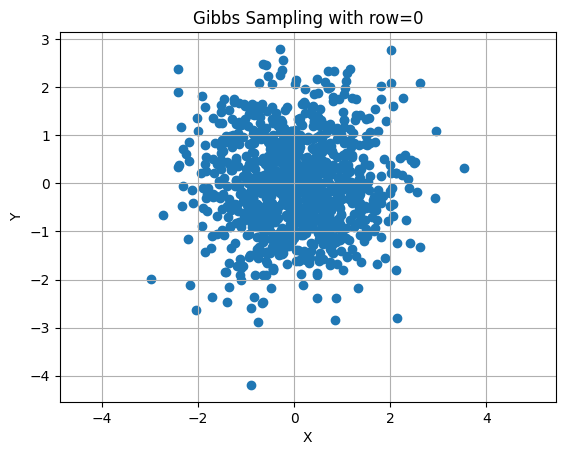

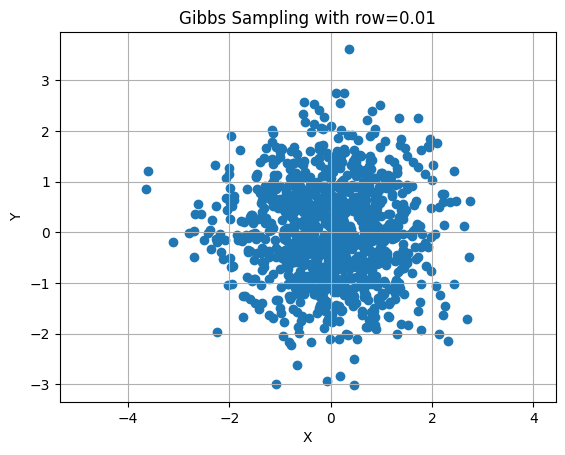

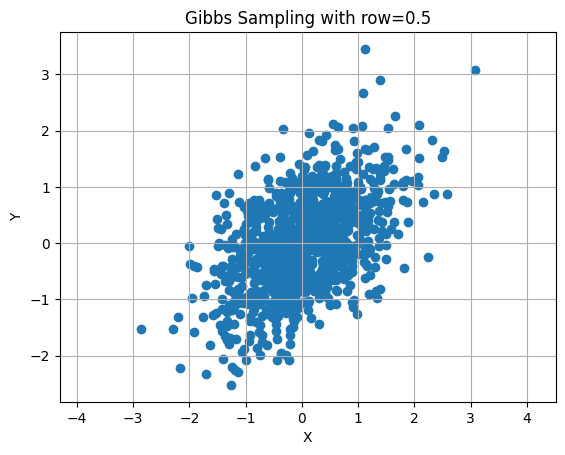

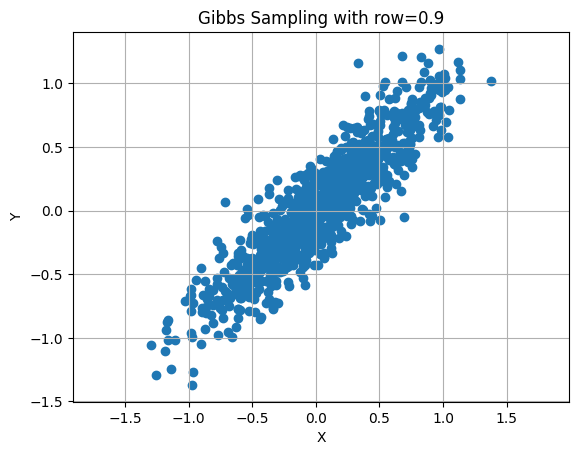

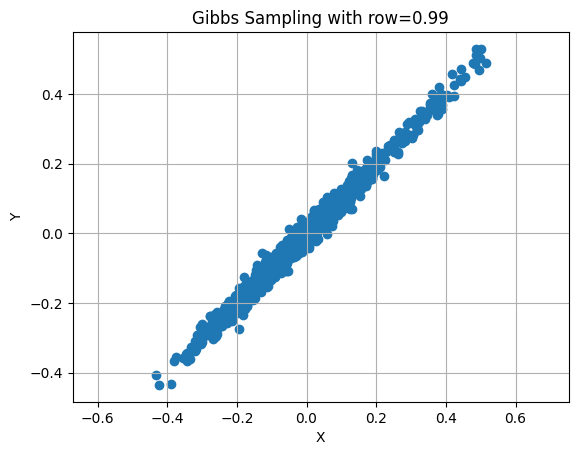

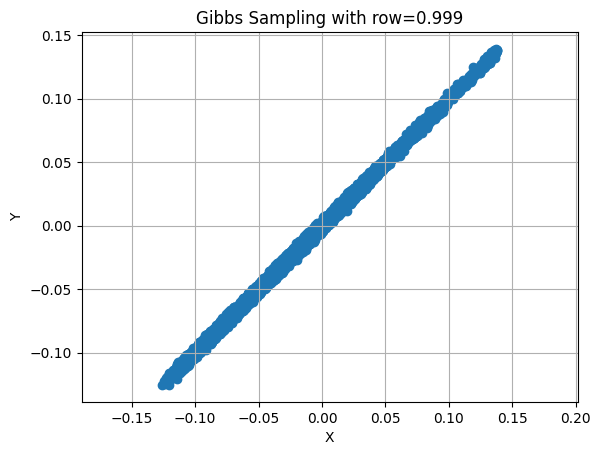

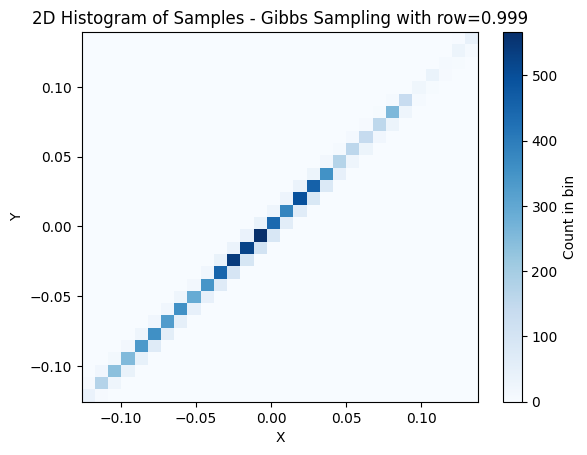

[[0. 0.]
 [0. 0.]
 [0. 0.]
 ...
 [0. 0.]
 [0. 0.]
 [0. 0.]]


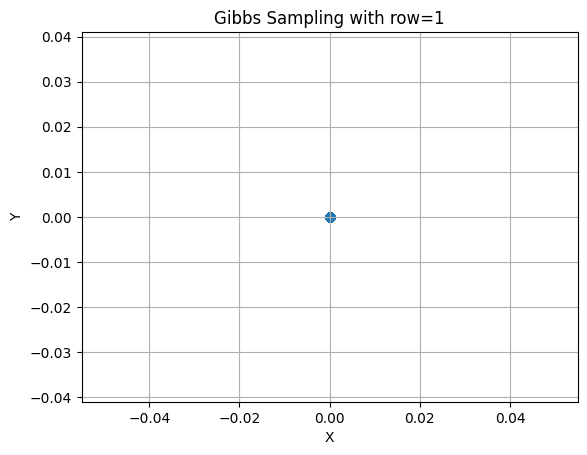

In [30]:
num_samples = 1000
row = 0
samples0 = gibbs_sampling(row, num_samples)
# print(samples0)
plot_samples(samples0, f'Gibbs Sampling with row={row}')

row = 0.01
samples1 = gibbs_sampling(row, num_samples)
# print(samples1)
plot_samples(samples1, f'Gibbs Sampling with row={row}')

row = 0.5
samples1 = gibbs_sampling(row, num_samples)
# print(samples1)
plot_samples(samples1, f'Gibbs Sampling with row={row}')

row = 0.9
samples2 = gibbs_sampling(row, num_samples)
# print(samples2)
plot_samples(samples2, f'Gibbs Sampling with row={row}')

row = 0.99
samples3 = gibbs_sampling(row, num_samples = 1000)
# print(samples3)
plot_samples(samples3, f'Gibbs Sampling with row={row}')

row = 0.999
samples4 = gibbs_sampling(row, num_samples = 10000)
# print(samples4)
plot_samples(samples4, f'Gibbs Sampling with row={row}')
# plot_samples_with_fit_line(samples4, f'Gibbs Sampling with row={row} and Fit Line')
plot_histogram(samples4, f'Gibbs Sampling with row={row}')

row = 1
samples5 = gibbs_sampling(row, num_samples = 1000)
print(samples5)
plot_samples(samples5, f'Gibbs Sampling with row={row}')

In [ ]:
# From the bivariate gaussian distribution extract the values of x and y to form histogram and see whether it is normal distribution?
# Further plot the gaussian distribution of mean abd variance = sqrt(1-row^2) and see whether it matches with the histogram of x and y values.


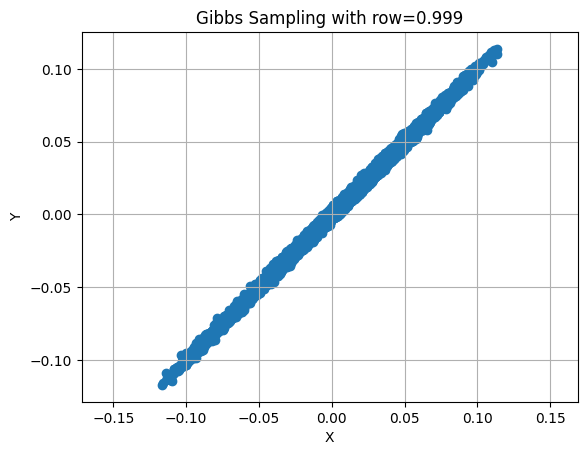

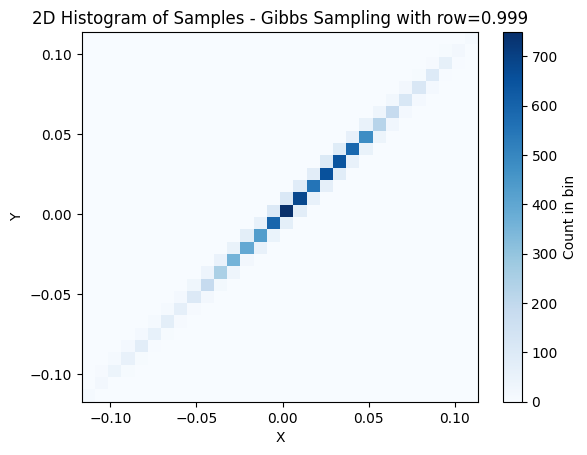

In [ ]:
row = 0.999
samples4 = gibbs_sampling(row, num_samples = 10000)
# print(samples4)
plot_samples(samples4, f'Gibbs Sampling with row={row}')
# plot_samples_with_fit_line(samples4, f'Gibbs Sampling with row={row} and Fit Line')
plot_histogram(samples4, f'Gibbs Sampling with row={row}')

In [8]:
import numpy as np
def gibbs_sampling1(row=0.5, num_samples=1000):
    samples = np.zeros((num_samples, 2))
    x, y = 0, 0

    std = np.sqrt(1 - row**2)   # FIX

    for i in range(num_samples):
        x = np.random.normal(row * y, std)
        y = np.random.normal(row * x, std)
        samples[i] = [x, y]

    return samples

In [9]:
samples = gibbs_sampling1(row=0.5, num_samples=10000)

x_vals = samples[:, 0]
y_vals = samples[:, 1]

In [16]:
import matplotlib.pyplot as plt

def plot_histogram_with_pdf(x_vals, y_vals, row):
    x_axis = np.linspace(-4, 4, 1000)
    
    # Standard normal PDF
    std = np.sqrt(1 - row**2)
    pdf = (1 / (std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * (x_axis / std) ** 2)

    plt.hist(x_vals, bins=50, density=True, alpha=0.5, label='x samples')
    plt.plot(x_axis, pdf, label='True Normal PDF', linewidth=2)

    plt.hist(y_vals, bins=50, density=True, alpha=0.5, label='y samples')
    plt.plot(x_axis, pdf, label='True Normal PDF', linewidth=2)

    plt.legend()
    plt.title("Histogram of x and y (Gibbs Samples)")
    plt.show()

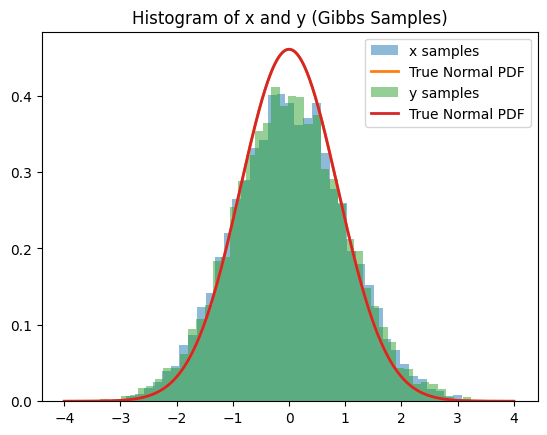

In [17]:
# Plot histogram of x and y values with the true normal PDF
plot_histogram_with_pdf(x_vals, y_vals, row=0.5)

In [ ]:
# Get the burning period and plot
def get_burning_period(samples, row):
    x_vals = samples[:, 0]
    y_vals = samples[:, 1]

    # Calculate the mean and variance of the samples
    mean_x = np.mean(x_vals)
    mean_y = np.mean(y_vals)
    var_x = np.var(x_vals)
    var_y = np.var(y_vals)

    # Theoretical mean and variance for the bivariate normal distribution
    theoretical_mean = 0
    theoretical_var = 1 - row**2

    # Check when the sample mean and variance are close to the theoretical values
    burning_period = 0
    for i in range(len(samples)):
        if (abs(np.mean(x_vals[:i]) - theoretical_mean) < 0.1 and
            abs(np.mean(y_vals[:i]) - theoretical_mean) < 0.1 and
            abs(np.var(x_vals[:i]) - theoretical_var) < 0.1 and
            abs(np.var(y_vals[:i]) - theoretical_var) < 0.1):
            burning_period = i
            break

    return burning_period


/home/tilak/projects/tilak/mds/myenv/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tilak/projects/tilak/mds/myenv/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Burning period: 0 samples


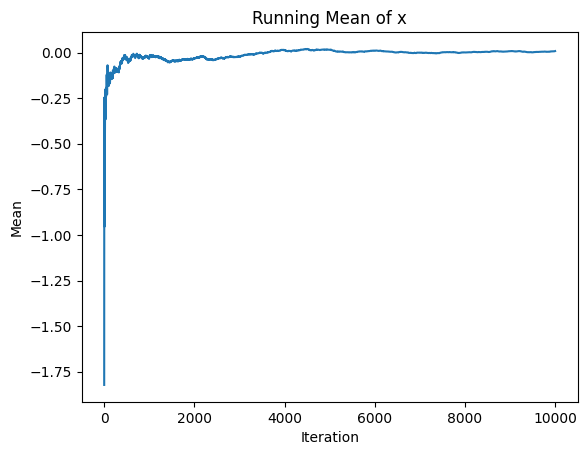

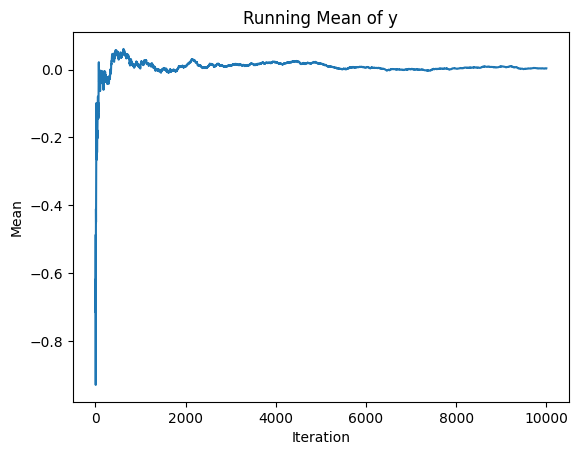

In [24]:
running_mean_x = np.cumsum(x_vals) / np.arange(1, len(x_vals)+1)
running_mean_y = np.cumsum(y_vals) / np.arange(1, len(y_vals)+1)

plt.plot(running_mean_x)
plt.title("Running Mean of x")
plt.xlabel("Iteration")
plt.ylabel("Mean")
plt.show()

plt.plot(running_mean_y)
plt.title("Running Mean of y")
plt.xlabel("Iteration")
plt.ylabel("Mean")
plt.show()

In [26]:
# find stabalizing point

tolerance = 0.01   # small change threshold
window = 50        # check stability over last 50 points

burn_in_x = 0

for i in range(window, len(running_mean_x)):
    recent = running_mean_x[i-window:i]
    if np.max(recent) - np.min(recent) < tolerance:
        burn_in_x = i
        break

print("Estimated burn-in for x:", burn_in_x)



Estimated burn-in for x: 874


In [34]:
# Create a gibbs functions

import numpy as np

def gibbs_sampling(rho=0.5, num_samples=1000, init=(0, 0)):
    samples = np.zeros((num_samples, 2))
    x, y = init

    std = np.sqrt(1 - rho**2)

    for i in range(num_samples):
        x = np.random.normal(rho * y, std)
        y = np.random.normal(rho * x, std)
        samples[i] = [x, y]

    return samples

# Running mean function
def running_mean(x):
    return np.cumsum(x) / np.arange(1, len(x) + 1)

# Burin in detection function
def estimate_burn_in(x_vals, tolerance=0.01, window=50):
    r_mean = running_mean(x_vals)

    for i in range(window, len(r_mean)):
        recent = r_mean[i-window:i]
        if np.max(recent) - np.min(recent) < tolerance:
            return i  # burn-in index

    return None  # if not found

# plot trace plot and burnin function
import matplotlib.pyplot as plt

def plot_trace_with_burnin(x_vals, burn_in):
    # plt.plot(x_vals, label='x values', alpha=0.7)
    plt.plot(running_mean(x_vals), label='Running Mean of x', color='blue')
    plt.axvline(burn_in, color='red', linestyle='--', label=f'Burn-in = {burn_in}')
    
    plt.title("Trace Plot with Burn-in")
    plt.xlabel("Iteration")
    plt.ylabel("Value")
    plt.legend()
    plt.show()

# function histogram with pdf
def plot_histogram_with_gaussian(x_vals):
    x_axis = np.linspace(-4, 4, 1000)
    pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * x_axis**2)

    plt.hist(x_vals, bins=50, density=True, alpha=0.5, label='Samples')
    plt.plot(x_axis, pdf, label='True N(0,1)', linewidth=2)

    plt.legend()
    plt.title("Histogram vs Gaussian")
    plt.show()

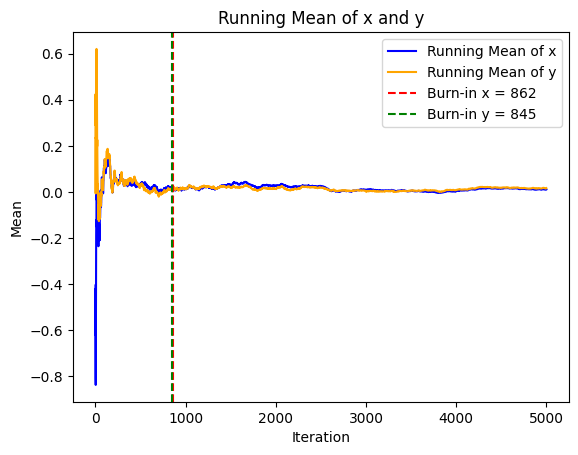

Burn-in: 862


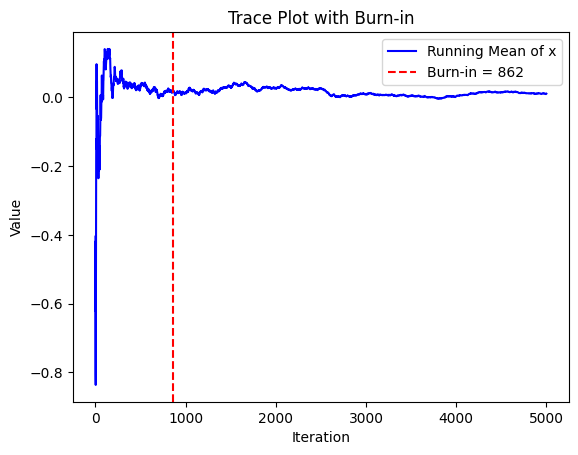

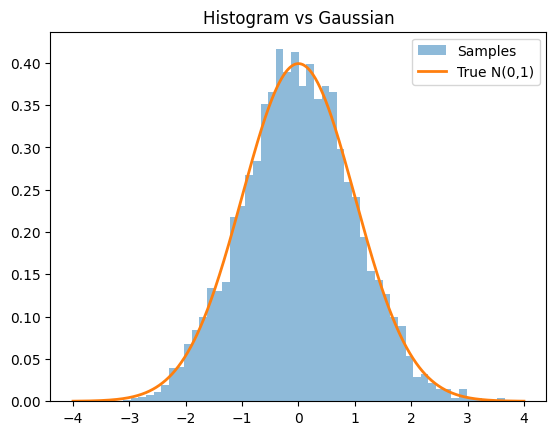

In [ ]:
# Step 1: Generate samples
samples = gibbs_sampling(rho=0.5, num_samples=5000)

x_vals = samples[:, 0]
y_vals = samples[:, 1]

# Step 2: Estimate burn-in
burn_in_x = estimate_burn_in(x_vals)
burn_in_y = estimate_burn_in(y_vals)

# plot running mean of x and y and the burn-in point
plt.plot(running_mean(x_vals), label='Running Mean of x', color='blue')
plt.plot(running_mean(y_vals), label='Running Mean of y', color='orange')
plt.axvline(burn_in_x, color='red', linestyle='--', label=f'Burn-in x = {burn_in_x}')
plt.axvline(burn_in_y, color='green', linestyle='--', label=f'Burn-in y = {burn_in_y}')
plt.title("Running Mean of x and y")
plt.xlabel("Iteration")
plt.ylabel("Mean")
plt.legend()
plt.show()

print("Burn-in:", burn_in_x)

# Step 3: Plot trace
plot_trace_with_burnin(x_vals, burn_in_x)

# Step 4: Remove burn-in
x_clean = x_vals[burn_in_x:]
y_clean = y_vals[burn_in_y:]

# Step 5: Check distribution
plot_histogram_with_gaussian(x_clean)